# Scene Classification on EO Imagery  
### SVM on ResNet Features vs ResNet50 Fine-tuning (UC Merced Dataset)

## Objective

This notebook compares a feature-based machine learning approach and an end-to-end deep learning model for scene classification on Earth Observation imagery.

We evaluate:

- SVM on deep features extracted from pretrained ResNet-18
- ResNet50 with transfer learning (fine-tuning)

Goal: understand the trade-off between fixed feature representations and task-specific feature learning.

## Workflow

1. Data loading and inspection  
2. Feature extraction (ResNet-18) + SVM classifier
3. ResNet50 fine-tuning
4. Performance comparison  

## Dataset

We use the UC Merced Land Use dataset:

- RGB imagery  
- Image size: 256 × 256 × 3  
- Multi-class land-use classification  

The dataset is split into training and test sets.

## Data Inspection

Sample images are visualized to verify class structure and variability across categories.

In [1]:
import torch, torchvision, torchgeo
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("TorchGeo:", torchgeo.__version__)

PyTorch: 2.10.0+cu126
TorchVision: 0.25.0+cu126
TorchGeo: 0.9.0


In [2]:
import os
import random
import math
import numpy as np
from pathlib import Path

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torchgeo.datasets import UCMerced

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Total images: 2100, Num classes: 21
Class names: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


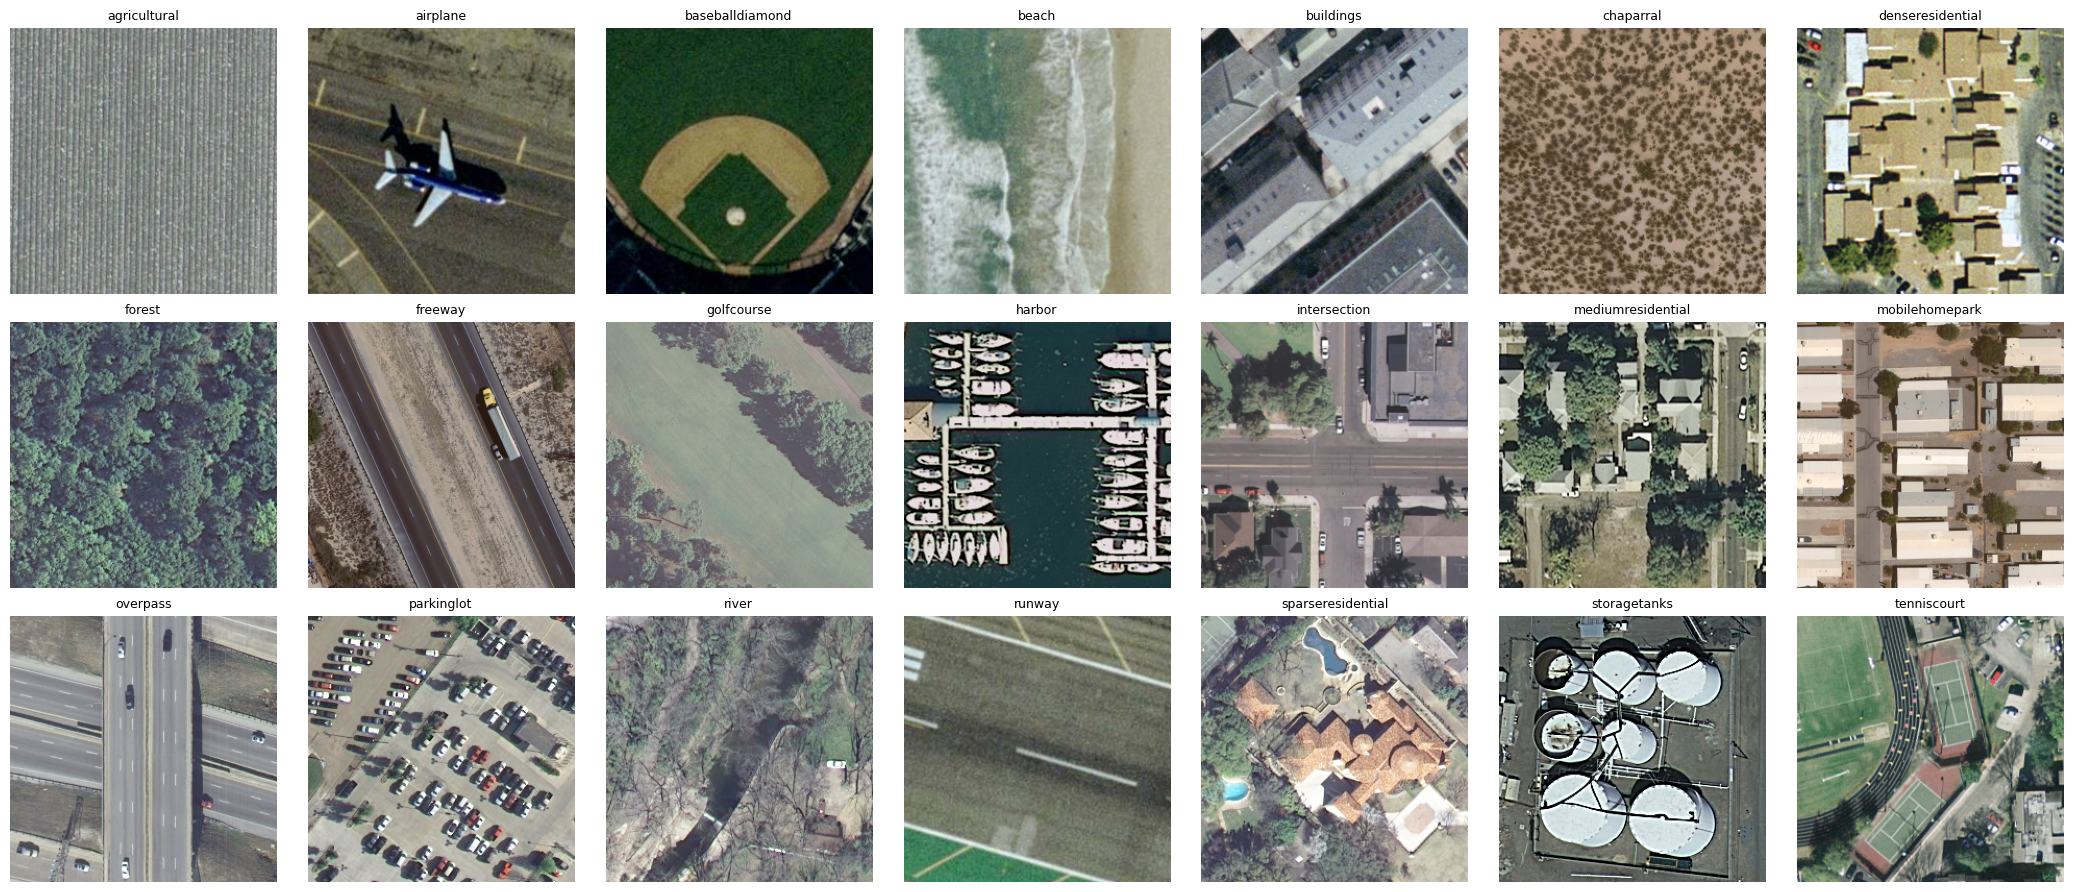

In [3]:
from torchvision.datasets import ImageFolder
DATA_ROOT = Path("./data/ucmerced")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

_ = UCMerced(root=DATA_ROOT, download=True)
data_dir = DATA_ROOT / "UCMerced_LandUse" / "Images"
ds_all = ImageFolder(root=data_dir)

# ImageNet normalization for transfer learning
IMG_SIZE = 224
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class WrappedUCM(torch.utils.data.Dataset):
    def __init__(self, base, transform=None):
        self.base = base
        self.transform = transform
        if isinstance(base, torch.utils.data.Subset):
            self.classes = base.dataset.classes
        else:
            self.classes = base.classes

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, label


wrapped_all = WrappedUCM(ds_all, transform=None)

num_classes = len(wrapped_all.classes)
print(f"Total images: {len(wrapped_all)}, Num classes: {num_classes}")
print("Class names:", wrapped_all.classes)

# Sample visualization (one image per class)
num_classes = len(wrapped_all.classes)
cols = 7
rows = (num_classes + cols - 1) // cols

plt.figure(figsize=(3*cols, 3*rows))

for class_idx, class_name in enumerate(wrapped_all.classes):
    indices = [i for i, (_, label) in enumerate(ds_all) if label == class_idx]
    idx = random.choice(indices)
    img, _ = ds_all[idx]

    plt.subplot(rows, cols, class_idx + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Stratified 60/20/20 split
labels = []
for i in range(len(wrapped_all)):
    sample = ds_all[i]
    label = int(sample["label"] if isinstance(sample, dict) else sample[1])
    labels.append(label)

labels = np.array(labels)
indices_by_class = {c: np.where(labels == c)[0].tolist() for c in np.unique(labels)}

train_indices, val_indices, test_indices = [], [], []
train_ratio, val_ratio = 0.6, 0.2

rng = np.random.default_rng(SEED)
for c, idxs in indices_by_class.items():
    rng.shuffle(idxs)
    n_total = len(idxs)
    n_train = int(math.floor(n_total * train_ratio))
    n_val = int(math.floor(n_total * val_ratio))
    train_indices.extend(idxs[:n_train])
    val_indices.extend(idxs[n_train:n_train+n_val])
    test_indices.extend(idxs[n_train+n_val:])

train_ds = WrappedUCM(Subset(ds_all, train_indices), transform=train_tf)
val_ds   = WrappedUCM(Subset(ds_all, val_indices),   transform=test_tf)
test_ds  = WrappedUCM(Subset(ds_all, test_indices),  transform=test_tf)

BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}, Test size: {len(test_ds)}")

Train size: 1260, Val size: 420, Test size: 420


## SVM on Deep Features (Baseline)

A Support Vector Machine (SVM) classifier is trained on features extracted from a pretrained ResNet-18 model.

Each image is passed through the network to obtain a 512-dimensional feature vector, preserving high-level visual structure.

This provides a strong feature-based baseline for comparison against end-to-end deep learning.

In [5]:
# Raw images in original order
images = np.stack([np.array(ds_all[i][0].resize((224, 224))) for i in range(len(ds_all))]).astype("float32") / 255.0
images = np.transpose(images, (0, 3, 1, 2))

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 3, 1, 1)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 3, 1, 1)
images = (images - mean) / std

# Training 
resnet18 = torchvision.models.resnet18(weights="IMAGENET1K_V1")
resnet18 = torch.nn.Sequential(*list(resnet18.children())[:-1])
resnet18.eval()

with torch.no_grad():
    features = resnet18(torch.from_numpy(images)).squeeze(-1).squeeze(-1).numpy()

X_train, X_test = features[train_indices], features[test_indices]
y_train, y_test = labels[train_indices], labels[test_indices]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_clf = SVC(kernel="rbf", C=1000, gamma=1e-5, random_state=123)
svm_clf.fit(X_train, y_train)

SVC(C=1000, gamma=1e-05, random_state=123)

## Evaluation — SVM (ResNet Features)

Performance is evaluated using accuracy and a confusion matrix.

Overall Accuracy (OA): 0.9190
Average Accuracy (AA): 0.9190


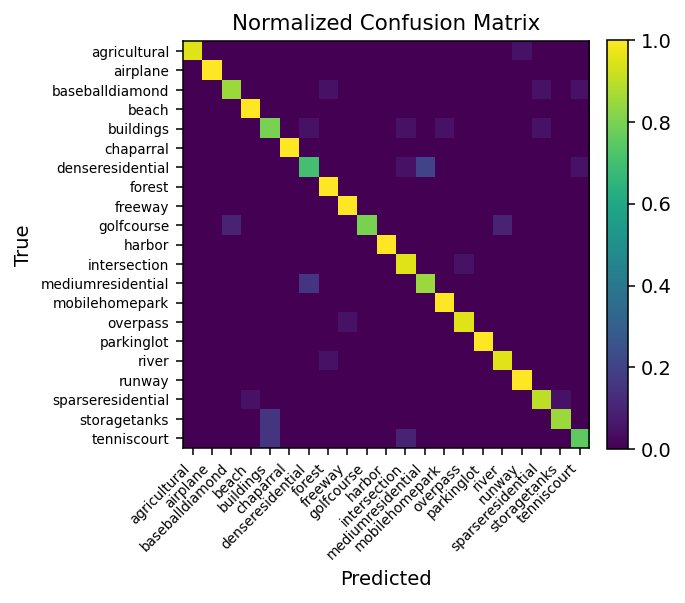


Per-class accuracy:
 0 - agricultural        : 0.9500
 1 - airplane            : 1.0000
 2 - baseballdiamond     : 0.8500
 3 - beach               : 1.0000
 4 - buildings           : 0.8000
 5 - chaparral           : 1.0000
 6 - denseresidential    : 0.7000
 7 - forest              : 1.0000
 8 - freeway             : 1.0000
 9 - golfcourse          : 0.8000
10 - harbor              : 1.0000
11 - intersection        : 0.9500
12 - mediumresidential   : 0.8500
13 - mobilehomepark      : 1.0000
14 - overpass            : 0.9500
15 - parkinglot          : 1.0000
16 - river               : 0.9500
17 - runway              : 1.0000
18 - sparseresidential   : 0.9000
19 - storagetanks        : 0.8500
20 - tenniscourt         : 0.7500


In [6]:
# === Evaluation: OA, AA, Confusion Matrix ===

# Predict
svm_preds = svm_clf.predict(X_test)
svm_targets = y_test

# Metrics
oa = accuracy_score(svm_targets, svm_preds)
print(f"Overall Accuracy (OA): {oa:.4f}")

class_names = wrapped_all.classes
num_classes = len(class_names)

cm = confusion_matrix(svm_targets, svm_preds, labels=list(range(num_classes)))
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
aa = float(np.nanmean(per_class_acc))
print(f"Average Accuracy (AA): {aa:.4f}")

# Visualization
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(5, 5), dpi=140)
im = ax.imshow(cm_norm, cmap="viridis", interpolation='nearest', vmin=0, vmax=1)

ax.set_title("Normalized Confusion Matrix", fontsize=11)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(class_names):
    print(f"{i:2d} - {name:20s}: {per_class_acc[i]:.4f}")

## ResNet50 (Deep Learning)

A pre-trained ResNet50 model is fine-tuned for scene classification.

The model preserves spatial structure and learns hierarchical visual features.

Transfer learning is used to improve performance under limited data conditions.

In [7]:
network = "resnet50"   # choose: "alexnet", "vgg16", "resnet18", "resnet50", "resnet101"

resnets = {
    "resnet18": models.resnet18,
    "resnet50": models.resnet50,
    "resnet101": models.resnet101
}

if network == "alexnet":
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(4096, num_classes)

elif network == "vgg16":
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(4096, num_classes)

elif network in resnets:
    model = resnets[network](weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
else:
    raise ValueError(f"Unsupported network: {network}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

In [8]:
# Training 
EPOCHS = 10 

def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    for images, targets in pbar:
        images, targets = images.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        pbar.set_postfix(loss=running_loss/total, acc=correct/total)
    return running_loss/total, correct/total

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Eval", leave=False):
            images, targets = images.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    acc = correct / total
    return acc, torch.cat(all_preds).numpy(), torch.cat(all_targets).numpy()

best_val_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
    val_acc, _, _ = evaluate(model, val_loader)
    print(f"Epoch {epoch+1:02d}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Optional: save best model checkpoint
        # Disabled by default to avoid unintended overwrites during repeated experiments
        # torch.save(model.state_dict(), "best_resnet50_ucm.pth")
        
print(f"Best Val Acc observed: {best_val_acc:.4f}")


Epoch 1/10 [train]:   0%|          | 0/20 [00:00<?, ?it/s]

Eval:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 01: Train Acc=0.5008 | Val Acc=0.8476


Epoch 2/10 [train]:   0%|          | 0/20 [00:00<?, ?it/s]

Eval:   0%|          | 0/7 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 09: Train Acc=0.9929 | Val Acc=0.9667


Epoch 10/10 [train]:   0%|          | 0/20 [00:00<?, ?it/s]

Eval:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10: Train Acc=0.9952 | Val Acc=0.9548
Best Val Acc observed: 0.9762


## Evaluation — RestNet50

Performance is evaluated using accuracy and a confusion matrix.

Eval:   0%|          | 0/7 [00:00<?, ?it/s]

Overall Accuracy (OA): 0.9857
Average Accuracy (AA): 0.9857


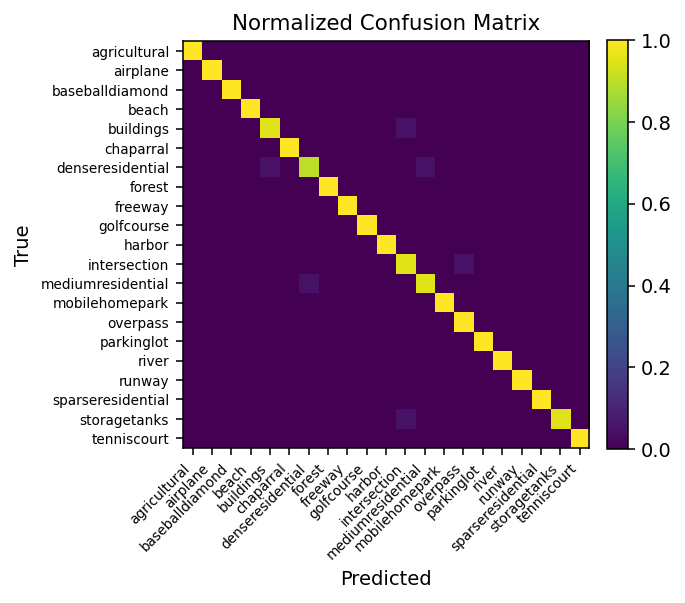


Per-class accuracy:
 0 - agricultural        : 1.0000
 1 - airplane            : 1.0000
 2 - baseballdiamond     : 1.0000
 3 - beach               : 1.0000
 4 - buildings           : 0.9500
 5 - chaparral           : 1.0000
 6 - denseresidential    : 0.9000
 7 - forest              : 1.0000
 8 - freeway             : 1.0000
 9 - golfcourse          : 1.0000
10 - harbor              : 1.0000
11 - intersection        : 0.9500
12 - mediumresidential   : 0.9500
13 - mobilehomepark      : 1.0000
14 - overpass            : 1.0000
15 - parkinglot          : 1.0000
16 - river               : 1.0000
17 - runway              : 1.0000
18 - sparseresidential   : 1.0000
19 - storagetanks        : 0.9500
20 - tenniscourt         : 1.0000


In [9]:
# === Evaluation: OA, AA, Confusion Matrix ===
# Load best checkpoint if available
if Path("best_resnet50_ucm.pth").exists():
    model.load_state_dict(
    torch.load("best_resnet50_ucm.pth", map_location=device, weights_only=True)
)

# Metrics
oa, preds, targets = evaluate(model, test_loader)
print(f"Overall Accuracy (OA): {oa:.4f}")

class_names = wrapped_all.classes
num_classes = len(wrapped_all.classes)

cm = confusion_matrix(targets, preds, labels=list(range(num_classes)))
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
aa = float(np.nanmean(per_class_acc))
print(f"Average Accuracy (AA): {aa:.4f}")

# Visualization
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(5, 5), dpi=140)
im = ax.imshow(cm_norm, cmap="viridis", interpolation='nearest' , vmin=0, vmax=1)

ax.set_title("Normalized Confusion Matrix", fontsize=11)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
for i, name in enumerate(class_names):
    print(f"{i:2d} - {name:20s}: {per_class_acc[i]:.4f}")

In [10]:
# Error analysis — collect misclassified test samples
mis_idx = np.where(preds != targets)[0]
mis_true = targets[mis_idx]
mis_pred = preds[mis_idx]
mis_images = [test_loader.dataset[i][0] for i in mis_idx]

# Count confusion pairs (true class -> predicted class)
from collections import Counter
pairs = [(class_names[t], class_names[p]) for t,p in zip(mis_true, mis_pred)]
pair_counts = Counter(pairs)

print("Misclassification counts (True → Pred):")
for (t,p), c in pair_counts.most_common():
    print(f"{t:20s} → {p:20s}: {c}")

Misclassification counts (True → Pred):
buildings            → intersection        : 1
denseresidential     → buildings           : 1
denseresidential     → mediumresidential   : 1
intersection         → overpass            : 1
mediumresidential    → denseresidential    : 1
storagetanks         → intersection        : 1


In [11]:
# Summary of correct vs incorrect predictions
print(f"Total misclassified images: {len(mis_images)}")

correct_idx = np.where(preds == targets)[0]
print(f"Total correctly classified images: {len(correct_idx)}")

Total misclassified images: 6
Total correctly classified images: 414


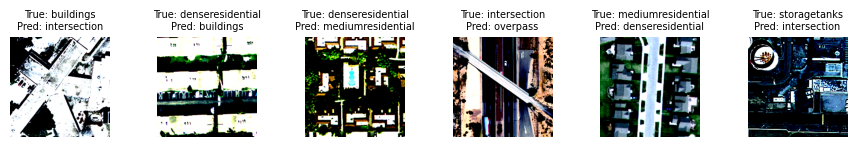

In [12]:
# Visualization — all misclassified test samples
cols = 6
rows = int(np.ceil(len(mis_images) / cols))

plt.figure(figsize=(cols*1.5, rows*1.5))  

for i in range(len(mis_images)):
    plt.subplot(rows, cols, i+1)

    img = mis_images[i].permute(1,2,0).numpy()
    img = np.clip(img, 0, 1) 

    plt.imshow(img)
    plt.title(f"True: {class_names[mis_true[i]]}\nPred: {class_names[mis_pred[i]]}", fontsize=7)
    plt.axis("off")

plt.tight_layout()
plt.show()

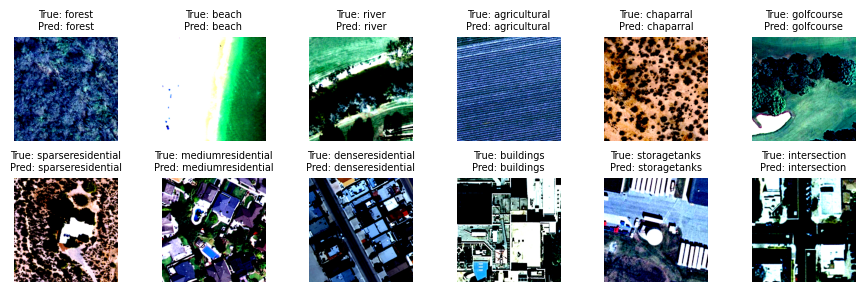

In [13]:
# Visualization — one correctly classified sample per selected class
chosen_classes = ['forest', 'beach', 'river', 'agricultural', 'chaparral', 'golfcourse',
                  'sparseresidential', 'mediumresidential', 'denseresidential', 'buildings', 'storagetanks','intersection']
sample_idx = []

for class_name in chosen_classes:
    class_id = class_names.index(class_name)
    
    indices = [i for i in correct_idx if targets[i] == class_id]
    
    picked = indices[2]
    sample_idx.append(picked)

sample_images = [test_loader.dataset[i][0] for i in sample_idx]
sample_true   = [targets[i] for i in sample_idx]
sample_preds  = [preds[i] for i in sample_idx]

cols = 6
rows = 2

plt.figure(figsize=(cols*1.5, rows*1.5))

for i in range(len(sample_images)):
    plt.subplot(rows, cols, i+1)

    img = sample_images[i].permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(
        f"True: {class_names[sample_true[i]]}\nPred: {class_names[sample_preds[i]]}",
        fontsize=7
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## Experimental Notes

Several variations were explored to understand what actually improves performance beyond the baseline.

- Data augmentation (crop, flip, rotation, color jitter) did not lead to consistent gains and occasionally reduced accuracy. This suggests that scene classification relies on global spatial layout, which can be disrupted by aggressive transformations.

- Switching from Adam to SGD with momentum resulted in slightly better generalization. The best configuration used a learning rate of 1e-2 with momentum (0.9) and weight decay (1e-4), while learning rate scheduling provided no clear benefit in this setup.
  
- Changing network architecture shows a clear performance hierarchy (ResNet > VGG16 > AlexNet), indicating that deeper models with residual connections learn more effective spatial representations.

- Increasing model complexity (ResNet50/101) significantly increased training time but did not improve validation performance, likely due to limited dataset size and overfitting. Similarly, training from scratch (without ImageNet pretraining) led to a substantial drop in accuracy, confirming the importance of transfer learning.

- Performance improved quickly in early epochs and saturated around 10–20 epochs, with longer training providing minimal gains.

- Error analysis shows that most misclassifications occur between visually similar classes (e.g., residential types and road structures), reflecting inherent ambiguity in spatial patterns.

- Overall, these observations indicate that performance is primarily constrained by dataset size, and that simple, well-tuned models with preserved spatial structure are sufficient for this task.

## Model Comparison

| Model                   | Input Representation        | Strength                              | Limitation                          | OA (%) |
| ----------------------- | --------------------------- | ------------------------------------- | ----------------------------------- | ------ |
| SVM (ResNet18 features) | Deep feature vector (512-d) | Strong baseline, low data requirement | Limited task-specific adaptation    | 91.9   |
| AlexNet                 | Image (spatial structure)   | Learns basic visual features          | Limited depth, weaker performance   | 86.4   |
| VGG16                   | Image (spatial structure)   | Deeper feature extraction             | High computation, no residual links | 82.9   |
| ResNet18                | Image (spatial structure)   | Strong feature learning (residuals)   | Higher computational cost           | 97.1   |
| ResNet50                | Image (spatial structure)   | Very deep representation              | Overfitting risk on small data      | 98.6   |
| ResNet101               | Image (spatial structure)   | Extremely deep features               | Diminishing returns, high cost      | 96.7   |

Key observations:

- ResNet50 outperforms feature-based SVM baseline
- Classical ML struggles with texture and contextual patterns  

## Conclusion
- Spatial structure is critical for scene classification
- CNN-based representation learning outperforms feature-based methods
- Classical ML remains competitive under limited data
- Deeper architectures (ResNet) outperform AlexNet/VGG due to stronger feature representation 

This comparison highlights the central role of representation in Earth Observation machine learning workflows.